## Imports

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("EarlySignal AI — Notebook 02")
print("Exploratory Analysis & Early Warning Patterns")

EarlySignal AI — Notebook 02
Exploratory Analysis & Early Warning Patterns


## Load dataset

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "synthetic"
    / "earlysignal_monitoring_data.csv"
)

df = pd.read_csv(DATA_PATH)

df["reporting_date"] = pd.to_datetime(df["reporting_date"])

print("Dataset loaded:", DATA_PATH.exists())
print("Shape:", df.shape)
print("Date range:",
      df["reporting_date"].min().date(),
      "to",
      df["reporting_date"].max().date())

Dataset loaded: True
Shape: (7680, 22)
Date range: 2024-01-01 to 2026-08-01


## Confirm risk and anomaly distribution

In [3]:
risk_summary = (
    df["risk_label"]
    .value_counts()
    .to_frame("records")
)

risk_summary["percentage"] = (
    risk_summary["records"] / len(df) * 100
).round(2)

print("Risk distribution:")
display(risk_summary)

anomaly_summary = (
    df["anomaly_flag"]
    .value_counts()
    .to_frame("records")
)

anomaly_summary["percentage"] = (
    anomaly_summary["records"] / len(df) * 100
).round(2)

print("\nAnomaly distribution:")
display(anomaly_summary)

Risk distribution:


,records,percentage
risk_label,,
Low,4245,55.27
Medium,2759,35.92
High,676,8.80



Anomaly distribution:


,records,percentage
anomaly_flag,,
0,7488,97.5
1,192,2.5


## Core performance indicators

In [4]:
performance_cols = [
    "monthly_target",
    "monthly_achievement",
    "achievement_rate",
    "activity_completion_rate",
    "budget_utilisation_rate",
    "reporting_delay_days",
    "staff_availability_rate",
    "supply_delay_days",
    "access_constraint_score",
    "data_quality_score"
]

df[performance_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
monthly_target,7680.0,648.205,225.745,188.000,462.000,654.000,837.000,1200.000
monthly_achievement,7680.0,469.880,168.902,88.000,337.000,463.500,600.000,1016.000
achievement_rate,7680.0,0.729,0.090,0.194,0.672,0.730,0.788,1.030
activity_completion_rate,7680.0,0.748,0.070,0.471,0.701,0.750,0.797,0.977
budget_utilisation_rate,7680.0,0.815,0.087,0.439,0.757,0.814,0.873,1.173
reporting_delay_days,7680.0,5.219,3.515,0.000,3.000,5.000,6.000,49.000
staff_availability_rate,7680.0,0.880,0.042,0.706,0.852,0.880,0.910,1.000
supply_delay_days,7680.0,5.583,3.888,0.000,3.000,5.000,7.000,54.000
access_constraint_score,7680.0,0.304,0.079,0.026,0.249,0.301,0.353,0.674
data_quality_score,7680.0,0.903,0.045,0.733,0.873,0.903,0.934,1.000


## Achievement by risk level

In [5]:
risk_order = ["Low", "Medium", "High"]

achievement_by_risk = (
    df.groupby("risk_label")[
        [
            "achievement_rate",
            "activity_completion_rate",
            "reporting_delay_days",
            "staff_availability_rate",
            "supply_delay_days",
            "access_constraint_score",
            "data_quality_score"
        ]
    ]
    .mean()
    .reindex(risk_order)
    .round(3)
)

achievement_by_risk

,achievement_rate,activity_completion_rate,reporting_delay_days,staff_availability_rate,supply_delay_days,access_constraint_score,data_quality_score
risk_label,,,,,,,
Low,0.782,0.776,4.241,0.884,4.725,0.287,0.906
Medium,0.680,0.720,5.801,0.877,6.004,0.322,0.900
High,0.593,0.685,8.988,0.873,9.249,0.337,0.897


## Visualize achievement by risk

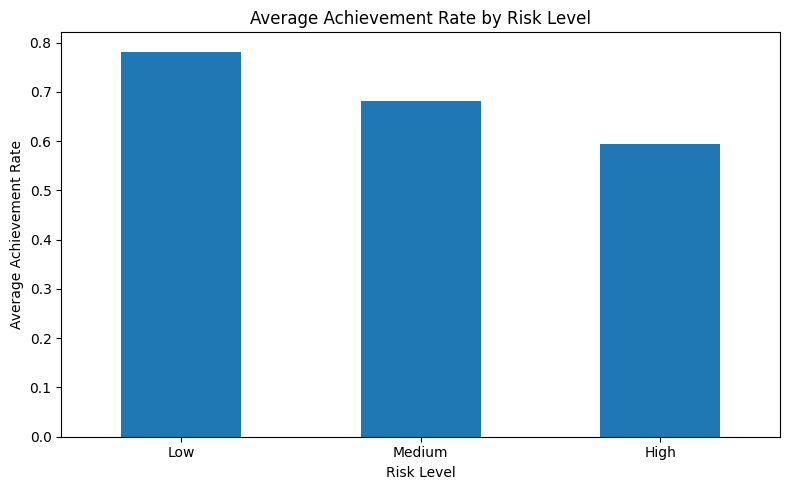

In [6]:
plot_data = (
    df.groupby("risk_label")["achievement_rate"]
    .mean()
    .reindex(risk_order)
)

plt.figure(figsize=(8, 5))
plot_data.plot(kind="bar")

plt.title("Average Achievement Rate by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Achievement Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Reporting delay versus risk

In [7]:
reporting_by_risk = (
    df.groupby("risk_label")["reporting_delay_days"]
    .agg(["mean", "median", "max"])
    .reindex(risk_order)
    .round(2)
)

reporting_by_risk

,mean,median,max
risk_label,,,
Low,4.24,4.0,17
Medium,5.80,5.0,48
High,8.99,7.0,49


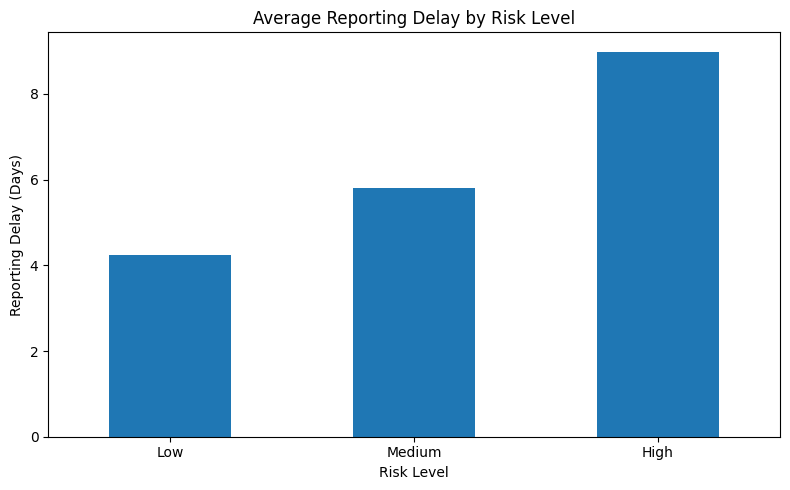

In [8]:
# Then visualize it:

plt.figure(figsize=(8, 5))

(
    df.groupby("risk_label")["reporting_delay_days"]
    .mean()
    .reindex(risk_order)
    .plot(kind="bar")
)

plt.title("Average Reporting Delay by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Reporting Delay (Days)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Activity completion versus risk

In [9]:
activity_by_risk = (
    df.groupby("risk_label")["activity_completion_rate"]
    .mean()
    .reindex(risk_order)
)

activity_by_risk

risk_label
Low       0.775981
Medium    0.720215
High      0.685231
Name: activity_completion_rate, dtype: float64

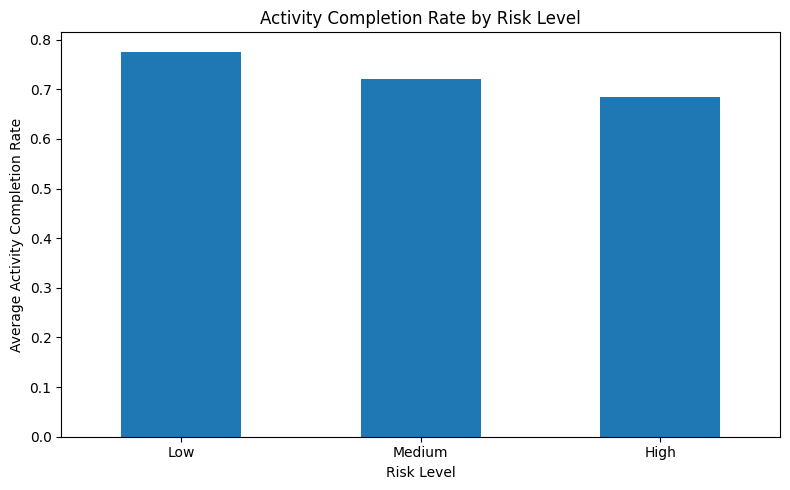

In [10]:
# Visualize:

plt.figure(figsize=(8, 5))

activity_by_risk.plot(kind="bar")

plt.title("Activity Completion Rate by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Activity Completion Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Operational factors by risk

In [11]:
operational_by_risk = (
    df.groupby("risk_label")[
        [
            "staff_availability_rate",
            "supply_delay_days",
            "access_constraint_score",
            "data_quality_score",
            "budget_utilisation_rate"
        ]
    ]
    .mean()
    .reindex(risk_order)
    .round(3)
)

operational_by_risk

,staff_availability_rate,supply_delay_days,access_constraint_score,data_quality_score,budget_utilisation_rate
risk_label,,,,,
Low,0.884,4.725,0.287,0.906,0.820
Medium,0.877,6.004,0.322,0.900,0.811
High,0.873,9.249,0.337,0.897,0.802


## Correlations with achievement

In [12]:
analysis_features = [
    "monthly_target",
    "monthly_achievement",
    "achievement_rate",
    "activity_completion_rate",
    "budget_utilisation_rate",
    "reporting_delay_days",
    "complaints_count",
    "staff_availability_rate",
    "supply_delay_days",
    "previous_month_achievement_rate",
    "access_constraint_score",
    "data_quality_score"
]

correlations = (
    df[analysis_features]
    .corr()["achievement_rate"]
    .sort_values(ascending=False)
    .round(3)
)

correlations

achievement_rate                   1.000
previous_month_achievement_rate    0.628
activity_completion_rate           0.293
monthly_achievement                0.223
budget_utilisation_rate            0.102
staff_availability_rate            0.084
data_quality_score                 0.039
supply_delay_days                 -0.095
complaints_count                  -0.096
monthly_target                    -0.125
reporting_delay_days              -0.134
access_constraint_score           -0.156
Name: achievement_rate, dtype: float64

## Correlation heatmap

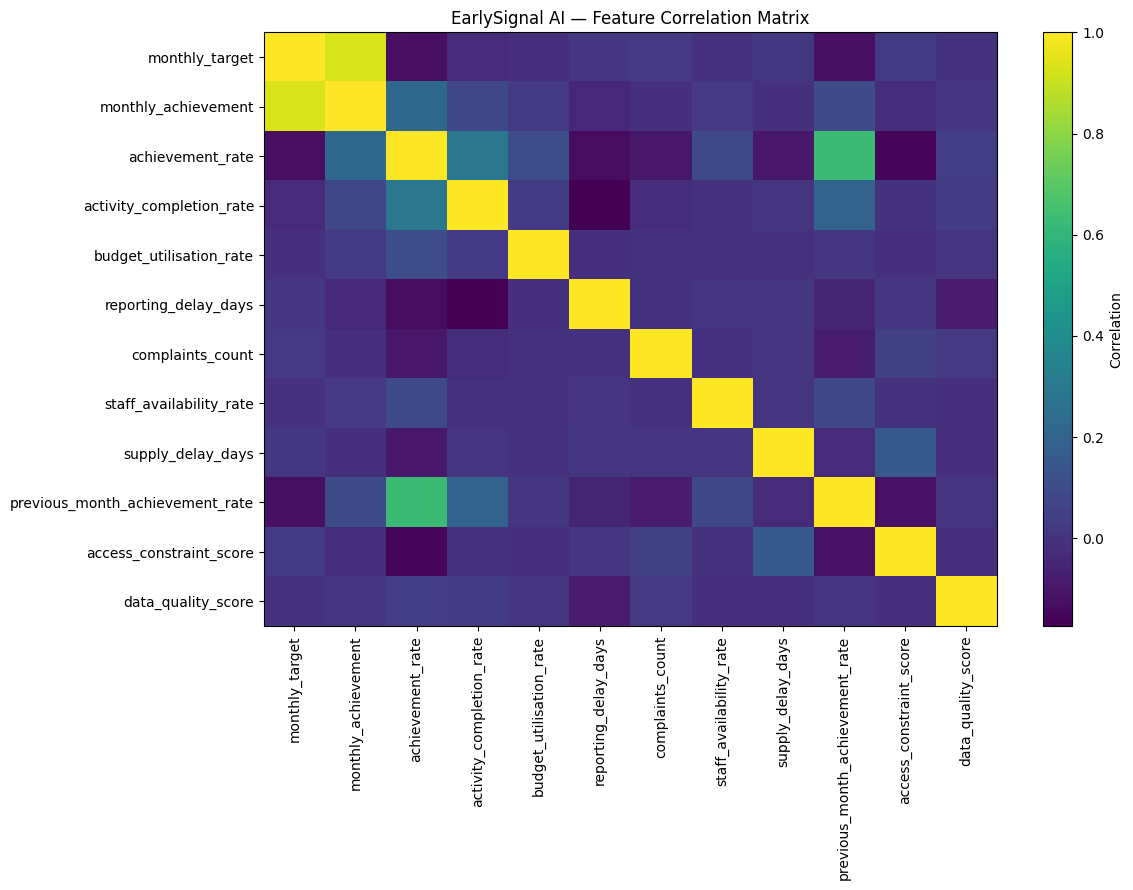

In [13]:
corr_matrix = df[analysis_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))

image = ax.imshow(corr_matrix, aspect="auto")

ax.set_xticks(range(len(analysis_features)))
ax.set_yticks(range(len(analysis_features)))

ax.set_xticklabels(
    analysis_features,
    rotation=90
)

ax.set_yticklabels(analysis_features)

plt.colorbar(image, ax=ax, label="Correlation")

plt.title("EarlySignal AI — Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## Underperformance definition
For exploration, define underperformance as achievement below 80% of target:

In [14]:
df["underperformance_flag"] = (
    df["achievement_rate"] < 0.80
).astype(int)

underperformance_count = df["underperformance_flag"].sum()
underperformance_pct = (
    df["underperformance_flag"].mean() * 100
)

print("Underperforming observations:",
      f"{underperformance_count:,}")

print("Underperformance rate:",
      f"{underperformance_pct:.2f}%")

Underperforming observations: 6,084
Underperformance rate: 79.22%


## Compare normal vs underperforming observations

In [15]:
underperformance_comparison = (
    df.groupby("underperformance_flag")[
        [
            "activity_completion_rate",
            "budget_utilisation_rate",
            "reporting_delay_days",
            "complaints_count",
            "staff_availability_rate",
            "supply_delay_days",
            "access_constraint_score",
            "data_quality_score"
        ]
    ]
    .mean()
    .round(3)
)

underperformance_comparison.index = [
    "Not Underperforming",
    "Underperforming"
]

underperformance_comparison

,activity_completion_rate,budget_utilisation_rate,reporting_delay_days,complaints_count,staff_availability_rate,supply_delay_days,access_constraint_score,data_quality_score
Not Underperforming,0.777,0.828,4.553,2.829,0.886,5.038,0.285,0.907
Underperforming,0.740,0.812,5.394,3.263,0.879,5.726,0.308,0.902


## High-risk records by programme

In [16]:
high_risk = df[df["risk_label"] == "High"].copy()

high_risk_by_programme = (
    high_risk.groupby("programme_name")
    .size()
    .sort_values(ascending=False)
    .to_frame("high_risk_records")
)

high_risk_by_programme["share_of_high_risk_pct"] = (
    high_risk_by_programme["high_risk_records"]
    / len(high_risk)
    * 100
).round(2)

high_risk_by_programme

,high_risk_records,share_of_high_risk_pct
programme_name,,
Education Access Project,171,25.30
WASH Resilience Initiative,170,25.15
Livelihood Recovery Initiative,162,23.96
Nutrition Support Programme,102,15.09
Community Resilience Programme,71,10.50


## High-risk records by geography

In [17]:
high_risk_by_location = (
    high_risk.groupby(["state", "lga"])
    .size()
    .sort_values(ascending=False)
    .reset_index(name="high_risk_records")
)

high_risk_by_location.head(20)

,state,lga,high_risk_records
0,Borno,Gwoza,121
1,Borno,Mafa,103
2,Borno,Bama,95
3,Borno,Ngala,93
4,Borno,Dikwa,89
5,Borno,Konduga,66
6,Borno,Jere,61
7,Borno,Maiduguri,48


## Anomaly characteristics

In [18]:
anomaly_comparison = (
    df.groupby("anomaly_flag")[
        [
            "achievement_rate",
            "activity_completion_rate",
            "budget_utilisation_rate",
            "reporting_delay_days",
            "complaints_count",
            "staff_availability_rate",
            "supply_delay_days",
            "access_constraint_score",
            "data_quality_score"
        ]
    ]
    .mean()
    .round(3)
)

anomaly_comparison.index = [
    "Normal",
    "Anomaly"
]

anomaly_comparison

,achievement_rate,activity_completion_rate,budget_utilisation_rate,reporting_delay_days,complaints_count,staff_availability_rate,supply_delay_days,access_constraint_score,data_quality_score
Normal,0.731,0.748,0.815,5.020,3.028,0.880,5.382,0.304,0.903
Anomaly,0.633,0.749,0.811,12.995,8.828,0.884,13.422,0.304,0.902


## Combined warning signals

In [19]:
df["warning_signal_count"] = (
    (df["achievement_rate"] < 0.80).astype(int)
    + (df["activity_completion_rate"] < 0.70).astype(int)
    + (df["reporting_delay_days"] > 10).astype(int)
    + (df["staff_availability_rate"] < 0.70).astype(int)
    + (df["supply_delay_days"] > 10).astype(int)
    + (df["access_constraint_score"] > 0.60).astype(int)
    + (df["data_quality_score"] < 0.70).astype(int)
    + (df["anomaly_flag"] == 1).astype(int)
)

warning_distribution = (
    df["warning_signal_count"]
    .value_counts()
    .sort_index()
    .to_frame("records")
)

warning_distribution["percentage"] = (
    warning_distribution["records"]
    / len(df)
    * 100
).round(2)

warning_distribution

,records,percentage
warning_signal_count,,
0,1328,17.29
1,4200,54.69
2,1882,24.51
3,242,3.15
4,26,0.34
5,2,0.03


## Warning signals versus existing risk label

In [20]:
warning_by_risk = (
    df.groupby("risk_label")["warning_signal_count"]
    .agg(["mean", "median", "max"])
    .reindex(risk_order)
    .round(2)
)

warning_by_risk

,mean,median,max
risk_label,,,
Low,0.77,1.0,2
Medium,1.47,1.0,3
High,2.18,2.0,5


## Top potential early-warning cases

In [21]:
priority_preview = (
    df.sort_values(
        [
            "warning_signal_count",
            "achievement_rate",
            "reporting_delay_days"
        ],
        ascending=[False, True, False]
    )
)

priority_columns = [
    "reporting_date",
    "programme_name",
    "sector",
    "state",
    "lga",
    "achievement_rate",
    "activity_completion_rate",
    "reporting_delay_days",
    "staff_availability_rate",
    "supply_delay_days",
    "access_constraint_score",
    "data_quality_score",
    "anomaly_flag",
    "risk_label",
    "warning_signal_count",
    "recommended_action"
]

priority_preview[priority_columns].head(20)

,reporting_date,programme_name,sector,state,lga,achievement_rate,activity_completion_rate,reporting_delay_days,staff_availability_rate,supply_delay_days,access_constraint_score,data_quality_score,anomaly_flag,risk_label,warning_signal_count,recommended_action
4631,2025-12-01,Nutrition Support Programme,Nutrition,Borno,Bama,0.5131,0.6148,12,0.8929,46,0.2836,0.8600,1,High,5,Recommended for human review: investigate supp...
1510,2024-07-01,Community Resilience Programme,Protection/Resilience,Borno,Ngala,0.7096,0.6935,39,0.9266,12,0.3242,0.9028,1,High,5,Recommended for human review: investigate repo...
4192,2024-01-01,Livelihood Recovery Initiative,Livelihoods,Borno,Mafa,0.4249,0.8180,12,0.8566,13,0.3562,0.9703,1,High,4,Recommended for human review: examine target u...
3318,2025-11-01,Livelihood Recovery Initiative,Livelihoods,Borno,Dikwa,0.4726,0.6427,11,0.9015,11,0.3130,1.0000,0,High,4,Recommended for human review: examine target u...
3455,2026-08-01,Livelihood Recovery Initiative,Livelihoods,Borno,Dikwa,0.5137,0.6632,4,0.8736,35,0.3371,0.8873,1,High,4,Recommended for human review: investigate supp...
7064,2026-01-01,WASH Resilience Initiative,WASH,Borno,Konduga,0.5618,0.6237,11,0.8949,13,0.4184,0.9406,0,High,4,Recommended for human review: examine target u...
4553,2024-10-01,Livelihood Recovery Initiative,Livelihoods,Borno,Ngala,0.5784,0.6255,9,0.7937,42,0.4495,0.8226,1,High,4,Recommended for human review: investigate supp...
2067,2025-08-01,Education Access Project,Education,Borno,Gwoza,0.5858,0.6462,6,0.9117,50,0.3585,0.9101,1,High,4,Recommended for human review: investigate supp...
1381,2024-06-01,Community Resilience Programme,Protection/Resilience,Borno,Ngala,0.5975,0.6974,45,0.8411,8,0.3206,0.8818,1,High,4,Recommended for human review: investigate repo...
1643,2024-12-01,Education Access Project,Education,Borno,Bama,0.5993,0.6390,48,0.8469,4,0.3267,0.8705,1,High,4,Recommended for human review: investigate repo...


## Notebook summary

In [22]:
print("=" * 65)
print("EARLYSIGNAL AI — EXPLORATORY ANALYSIS SUMMARY")
print("=" * 65)

print(f"Total observations: {len(df):,}")

print(
    f"Underperforming observations (<80% achievement): "
    f"{df['underperformance_flag'].sum():,} "
    f"({df['underperformance_flag'].mean() * 100:.2f}%)"
)

print(
    f"High-risk observations: "
    f"{(df['risk_label'] == 'High').sum():,}"
)

print(
    f"Anomalies: "
    f"{df['anomaly_flag'].sum():,}"
)

print(
    f"Average warning signals — Low Risk: "
    f"{warning_by_risk.loc['Low', 'mean']:.2f}"
)

print(
    f"Average warning signals — Medium Risk: "
    f"{warning_by_risk.loc['Medium', 'mean']:.2f}"
)

print(
    f"Average warning signals — High Risk: "
    f"{warning_by_risk.loc['High', 'mean']:.2f}"
)

print("\nNotebook 02 complete.")

EARLYSIGNAL AI — EXPLORATORY ANALYSIS SUMMARY
Total observations: 7,680
Underperforming observations (<80% achievement): 6,084 (79.22%)
High-risk observations: 676
Anomalies: 192
Average warning signals — Low Risk: 0.77
Average warning signals — Medium Risk: 1.47
Average warning signals — High Risk: 2.18

Notebook 02 complete.
